The ``aaanalysis.pipe`` (``aap``) module provides high-level **golden pipelines** — stateless, one-call wrappers over the AAanalysis primitives. ``aap.obtain_samples`` is the **first** pipeline of a typical workflow: instead of hand-driving :class:`AAWindowSampler` (and, for positive-unlabeled problems, :class:`dPULearn`), the parameters simply **describe the sampling situation**. The known positives are the rows of ``df_seq`` carrying 1-based anchors in ``pos_col``; reference windows are drawn to balance them and returned as one labeled ``'segments'``-mode training set, alongside a quick balance / leakage / coverage report.

We load the ``DOM_GSEC`` example dataset (see [Breimann25]_) and mark a positive anchor at the center of every membrane-protein (``label == 1``); the remaining proteins carry no positive and form the cross-protein unlabeled pool:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import aaanalysis as aa
import aaanalysis.pipe as aap
aa.options["verbose"] = False

df_seq = aa.load_dataset(name="DOM_GSEC", n=20)[["entry", "sequence", "label"]].copy()
df_seq["pos"] = (df_seq["sequence"].str.len() // 2).astype(int)
df_seq.loc[df_seq["label"] == 0, "pos"] = np.nan   # proteins without a positive = unlabeled pool

aa.display_df(df_seq, n_rows=10, show_shape=True)

DataFrame shape: (40, 4)


,entry,sequence,label,pos
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,nan
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,nan
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,nan
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,nan
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,nan
6,P01135,MVPSAGQLALFALGI...LLKGRTACCHSETVV,0,nan
7,O43914,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,0,nan
8,P05556,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,0,nan
9,P16234,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,0,nan
10,P50895,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,0,nan


**Situation 1 — within-protein hard negatives (``strategy='same_protein'``).** A single call returns the balanced training set ``df_samples`` (positive ``Test`` windows plus sampled ``Negative`` windows), an optional summary plot, and the validation report ``df_eval``. ``n`` sets the number of references (default: match the positives); ``window_size`` sets the window length; ``seed`` makes it reproducible:

In [2]:
df_samples, ax, df_eval = aap.obtain_samples(df_seq, strategy="same_protein",
                                             n=20, window_size=9, seed=42)

aa.display_df(df_samples, n_rows=10, show_shape=True)

DataFrame shape: (40, 8)


,entry_win,entry,sequence,window,source_position,label,role,strategy
1,P05067_381-389,P05067,MLPGLALLLLAAWTA...GYENPTYKFFEQMQN,TPGDENEHA,385,1,Test,test
2,P14925_484-492,P14925,MAGRARSGLLLLLLG...EEEYSAPLPKPAPSS,QQPGEGPWE,488,1,Test,test
3,P70180_264-272,P70180,MRSLLLFTFSACVLL...RELREDSIRSHFSVA,RIMLAVHRH,268,1,Test,test
4,Q03157_323-331,Q03157,MGPTSPAARGQGRRW...HGYENPTYRFLEERP,ERRMRQINE,327,1,Test,test
5,Q06481_377-385,Q06481,MAATGTAAAAATGRL...GYENPTYKYLEQMQI,YFETSADDN,381,1,Test,test
6,P35613_188-196,P35613,MAAALFVLLGFALLG...HQNDKGKNVRQRNSS,TEFKVDSDD,192,1,Test,test
7,P35070_85-93,P35070,MDRAARCSGASSLPL...DITPINEDIEETNIA,VVAEQTPSC,89,1,Test,test
8,P09803_438-446,P09803,MGARCRSFSALLLLL...RFKKLADMYGGGEDD,LKTAKGLDF,442,1,Test,test
9,P19022_449-457,P19022,MCRIAGALRTLLPLL...PRFKKLADMYGGGDD,PIDFETNRM,453,1,Test,test
10,P16070_367-375,P16070,MDKFWWHAAWGLCLV...DETRNLQNVDMKIGV,LIHHEHHEE,371,1,Test,test


The ``df_eval`` report summarizes class balance, the number of source proteins, protein coverage, and the maximum identity of any sampled window to a test window (the leakage indicator):

In [3]:
aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (1, 6)


,n_positive,n_negative,balance_ratio,n_source_proteins,protein_coverage,max_similarity_to_test
1,20,20,1.000000,20,0.500000,0.333333


Set ``plot=True`` to also get a **sequence-logo comparison** of the sampled groups as the second return value — one information-content logo per ``role`` (e.g. ``Test`` vs ``Negative``), so you can directly compare their amino-acid composition and conservation. It returns a list of ``Axes`` (``None`` when ``plot=False``):

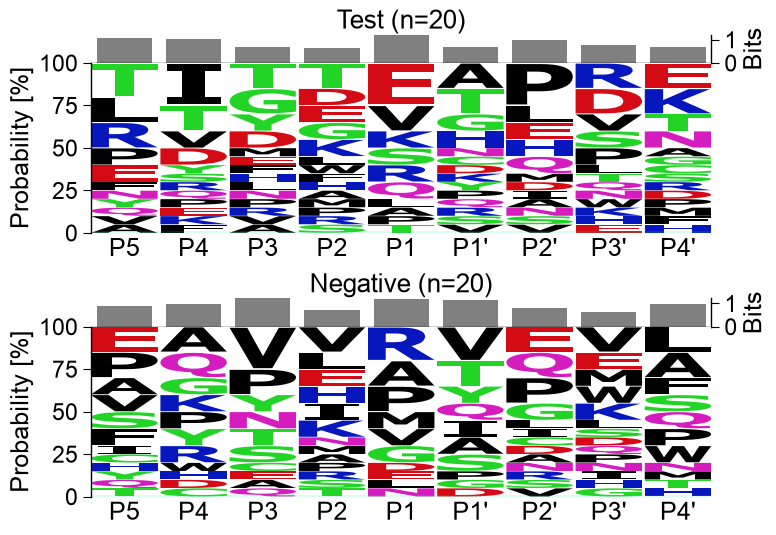

In [4]:
aa.plot_settings()
df_samples, ax, df_eval = aap.obtain_samples(df_seq, strategy="same_protein",
                                             n=20, window_size=9, plot=True, seed=42)
plt.tight_layout()
plt.show()

**Situation 2 — cross-protein unlabeled windows (``strategy='different_protein'``)** and **synthetic controls (``strategy='synthetic'``).** ``max_similarity_to_test`` drops sampled windows too similar to any test window (anti-leakage); ``verbose`` and ``n_jobs`` are threaded through:

In [5]:
df_diff, _, df_eval_diff = aap.obtain_samples(df_seq, strategy="different_protein",
                                              n=20, window_size=9,
                                              max_similarity_to_test=0.7,
                                              seed=42, verbose=False, n_jobs=1)
df_synth, _, _ = aap.obtain_samples(df_seq, strategy="synthetic", n=20, window_size=9, seed=42)

aa.display_df(df_eval_diff, n_rows=10, show_shape=True)

DataFrame shape: (1, 6)


,n_positive,n_negative,balance_ratio,n_source_proteins,protein_coverage,max_similarity_to_test
1,20,20,1.000000,15,0.375000,0.333333


**Reliable negatives (positive-unlabeled path).** Set ``reliable_negatives=True`` to refine the cross-protein unlabeled pool into reliable negatives with :class:`dPULearn`. This path requires a feature set ``df_feat`` (used to build the feature matrix ``X``) and ``strategy='different_protein'`` — it raises a clear error otherwise:

In [6]:
df_feat = aa.load_features().head(8)
df_rel, _, df_eval_rel = aap.obtain_samples(df_seq, strategy="different_protein",
                                            reliable_negatives=True, df_feat=df_feat,
                                            n=10, window_size=9, seed=42, n_jobs=1)

aa.display_df(df_eval_rel, n_rows=10, show_shape=True)

DataFrame shape: (1, 6)


/Users/stephanbreimann/Programming/1Packages/aa-wt-obtain-samples-logo/aaanalysis/pipe/_obtain_samples.py:134: UserWarning: 4 window(s) lack the flanking residues needed to build the feature matrix and are skipped on the reliable-negatives path; widen the sequences or lower 'window_size' to keep them.
  warnings.warn(f"{n_dropped} window(s) lack the flanking residues needed to build the "
/Users/stephanbreimann/Programming/1Packages/aa-wt-obtain-samples-logo/aaanalysis/feature_engineering/_backend/cpp_run.py:163: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


,n_positive,n_negative,balance_ratio,n_source_proteins,protein_coverage,max_similarity_to_test
1,20,10,0.500000,7,0.175000,0.333333


Passing ``pos_col`` selects a differently named anchor column. The returned ``df_samples`` is a ``'segments'``-mode ``df_seq`` ready to feed the next pipeline (e.g. ``aap.find_features``) — the positives and sampled references carry full provenance in the ``label`` / ``role`` / ``strategy`` columns.